## Auto-encodeurs

L'objectif de ce TP est de manipuler des auto-encodeurs sur un exemple simple : la base de données MNIST. L'idée est de pouvoir visualiser les concepts vus en cours, et notamment d'illustrer la notion d'espace latent.

Les images de la base de données MNIST sont des imagettes en niveaux de gris, de taille 28x28 pixels, représentant des chiffres manuscrits de 0 à 9.

![mnist](http://i.ytimg.com/vi/0QI3xgXuB-Q/hqdefault.jpg)




Pour démarrer, nous vous fournissons un code permettant de créer un premier auto-encodeur simple, de charger les données MNIST  et d'entraîner cet auto-encodeur. **L'autoencodeur n'est pas convolutif !** (libre à vous de le transformer pour qu'il le soit, plus tard dans le TP)

L'auto-encodeur implémenté ci-dessous compte 2 couches pour l'encodeur et deux couches pour le décodeur.


<img src="https://drive.google.com/uc?id=16OQjf9cX3dBS8brwxTe7kKed51spclLC" width=400>



On définit 3 modèles : l'encodeur, le décodeur, et l'auto-encodeur qui consiste en une concaténation des deux précédents.

On optimisera le modèle en minimisant l'erreur de reconstruction, ce que l'on fait classiquement en utilisant une erreur quadratique moyenne comme fonction de coût.

In [1]:
from keras.layers import Input, Dense
from keras.models import Model

# Dimension de l'entrée
input_img = Input(shape=(784,))
# Dimension de l'espace latent : PARAMETRE A TESTER !!
latent_dim = 32

# Définition d'un encodeur
x = Dense(128, activation='relu')(input_img)
encoded = Dense(latent_dim, activation='linear')(x)

# Définition d'un decodeur
decoder_input = Input(shape=(latent_dim,))
x = Dense(128, activation='relu')(decoder_input)
decoded = Dense(784, activation='sigmoid')(x)

# Construction d'un modèle séparé pour pouvoir accéder aux décodeur et encodeur
encoder = Model(input_img, encoded)
decoder = Model(decoder_input, decoded)

# Construction du modèle de l'auto-encodeur
encoded = encoder(input_img)
decoded = decoder(encoded)
autoencoder = Model(input_img, decoded)

# Utilisation de l'erreur quadratique moyenne comme fonction de coût
autoencoder.compile(optimizer='Adam', loss='bce')
autoencoder.summary()
print(encoder.summary())
print(decoder.summary())

I0000 00:00:1790586784.232355   25576 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790586789.062264   25576 gpu_device.cc:2036] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4113 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,360 (411.56 KB)

 Trainable params: 105,360 (411.56 KB)

 Non-trainable params: 0 (0.00 B)

None


In [2]:
from keras.datasets import mnist
import numpy as np

# Chargement et normalisation (entre 0 et 1) des données de la base de données MNIST
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Vectorisation des images d'entrée en vecteurs de dimension 784
x_train = np.reshape(x_train, (len(x_train), 784))
x_test = np.reshape(x_test, (len(x_test), 784))

In [3]:
# Entraînement de l'auto-encodeur. On utilise ici les données de test
# pour surveiller l'évolution de l'erreur de reconstruction sur des données
# non utilisées pendant l'entraînement et ainsi détecter le sur-apprentissage.
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))



Epoch 1/50


I0000 00:00:1790586809.911432   26445 service.cc:154] XLA service 0x7fb3c06b74d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790586809.911459   26445 service.cc:170]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.4.0[615.71.9]; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790586809.944232   26445 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790586814.919660   26557 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 40 bytes spill stores, 40 bytes spill loads

I0000 00:00:1790586816.917941   26557 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 8028 bytes spill stores, 8860 bytes spill loads

I0000 00:00:1790586819.845856   26445 cuda_dnn.cc:442] Lo

 67/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3390

I0000 00:00:1790586820.366883   26445 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1790586820.415844   26539 prefetch_dataset_op.cc:476] SEVERE STARVATION: Element UID 1790586809899417574 in buffer 'PrefetchDataset' sat unconsumed for 10.5164 seconds!


447/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1812

I0000 00:00:1790586826.267937   26870 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 40 bytes spill stores, 44 bytes spill loads

I0000 00:00:1790586827.071114   26867 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 8464 bytes spill stores, 9584 bytes spill loads



469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1785

I0000 00:00:1790586830.534295   27171 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 72 bytes spill stores, 40 bytes spill loads

I0000 00:00:1790586830.755406   27177 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 6992 bytes spill stores, 7988 bytes spill loads



469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - loss: 0.1785 - val_loss: 0.1188
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1099 - val_loss: 0.1011
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0989 - val_loss: 0.0949
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0942 - val_loss: 0.0912
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0911 - val_loss: 0.0888
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0892 - val_loss: 0.0873
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0878 - val_loss: 0.0864
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0868 - val_loss: 0.0853
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0859 - val_loss: 0.0846
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0852 - val_loss: 0.0841
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0845 - val_loss: 0.0835
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 

Le code suivant affiche des exemples d'images de la base de test (1e ligne) et de leur reconstruction (2e ligne).

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step


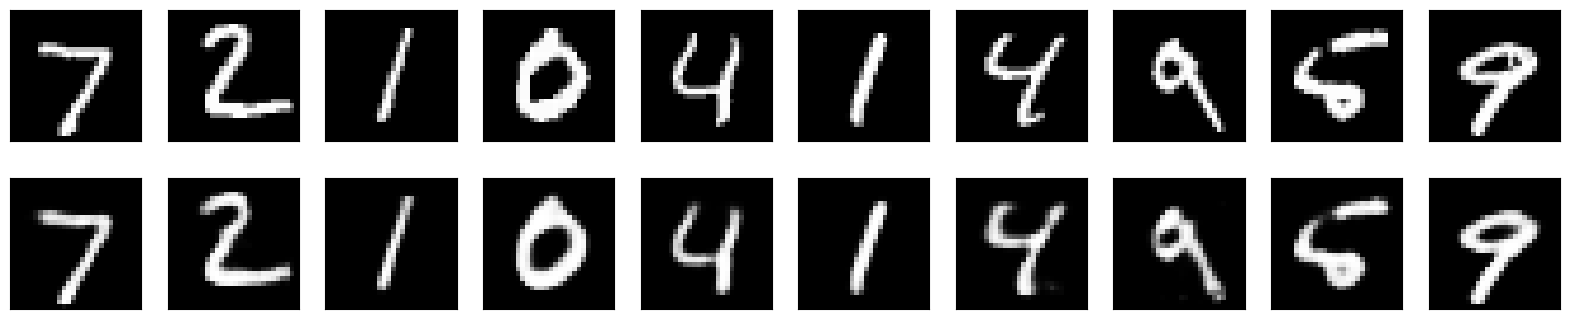

In [4]:
import matplotlib.pyplot as plt

# Prédiction des données de test
decoded_imgs = autoencoder.predict(x_test)


n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Affichage de l'image originale
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Affichage de l'image reconstruite par l'auto-encodeur
    ax = plt.subplot(2, n, i+1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# Travail à faire

1.   Pour commencer, observez les résultats obtenus avec le code fourni. Les résultats semblent imparfaits, les images reconstruites sont bruitées. Modifiez le code fourni pour transformer le problème de régression en classification binaire. Les résultats devraient être bien meilleurs ! Conservez cette formulation (même si elle est non standard) pour la suite.
2.   Avec la dimension d'espace latent qui vous est fournie, on observe une (relativement) faible erreur de reconstruction. Tracez une **courbe** (avec seulement quelques points) qui montre l'évolution de l'**erreur de reconstruction en fonction de la dimension de l'espace latent**. Quelle semble être la dimension minimale de l'espace latent qui permet encore d'observer une reconstruction raisonnable des données (avec le réseau qui vous est fourni) ?
3.   Pour diminuer encore plus la dimension de l'espace latent, il est nécessaire d'augmenter la capacité des réseaux encodeur et décodeur. Cherchez à nouveau la dimension minimale de l'espace latent qui permet d'observer une bonne reconstruction des données, mais en augmentant à l'envi la capacité de votre auto-encodeur.
4.   Écrivez une fonction qui, étant donné deux images de votre espace de test $I_1$ et $I_2$, réalise l'interpolation (avec, par exemple, 10 étapes) entre la représentation latente ($z_1 = $encoder($I_1$) et $z_2 = $encoder($I_2$)) de ces deux données, et génère les images $I_i$ correspondant aux représentations latentes intermédiaires $z_i$. En pseudo python, cela donne :

```python
for i in range(10):
  z_i = z1 + i*(z2-z1)/10
  I_i = decoder(z_i)
```
Testez cette fonction avec un auto-encodeur avec une faible erreur de reconstruction, sur deux données présentant le même chiffre écrit différemment, puis deux chiffres différents.

Vous devriez obtenir un résultat de ce type :    

<img src="https://drive.google.com/uc?id=1GATz2XrXOpnW-S7SzH-kvPzqNIHbaaiB">

5.   Pour finir, le code qui vous est fourni dans la suite permet de télécharger et de préparer une [base de données de visages](http://vis-www.cs.umass.edu/lfw/). ATTENTION : ici les images sont de taille $32\times32$, en couleur, et comportent donc 3 canaux (contrairement aux images de MNIST, qui n'en comptent qu'un). Par analogie avec la question précédente, on pourrait grâce à la représentation latente apprise par un auto-encodeur, réaliser un morphing entre deux visages. Essayez d'abord d'entraîner un auto-encodeur à obtenir une erreur de reconstruction faible. Qu'observe-t-on ?



## Réponses

2. Min dim latent 16 ok comme 32, mais 8 commence à être pas fou.
3. On ajoute une couche dense dans encoder et une couche dense dans decoder. Et ça améliore un peu à même dim espace latent.

5. indice : utiliser des couches de convolution, pas dense, donc faire sur images

In [1]:
from keras.datasets import mnist
import numpy as np

# Chargement et normalisation (entre 0 et 1) des données de la base de données MNIST
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

I0000 00:00:1790588313.981114   38580 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Conv2DTranspose, Reshape
from keras.models import Model
from matplotlib.axis import XAxis

epochs = 50

# Dimension de l'entrée
input_img = Input(shape=(28,28,1))

# Dimensions de l'espace latent : PARAMETRE A TESTER !!
latent_dims = [16]
last_val_losses = []
autoencoders = []
encoders = []
decoders = []

for l in latent_dims:
    print("Current latent dim :", l)

    # Définition d'un encodeur
    x = Conv2D(32, 3, activation='relu', padding="same")(input_img)
    x = MaxPooling2D((2, 2))(x)   # 28x28 -> 14x14

    x = Conv2D(64, 3, activation='relu', padding="same")(x)
    x = MaxPooling2D((2, 2))(x)   # 14x14 -> 7x7

    encoded = Flatten()(x)
    encoded = Dense(l, activation="linear")(encoded)


    # Définition d'un decodeur
    decoder_input = Input(shape=(l,))
    x = Dense(7 * 7 * 64, activation="relu")(decoder_input)
    x = Reshape((7, 7, 64))(x)
    x = Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    decoded = Conv2D(1, 3, activation="sigmoid", padding="same")(x)


    # Construction d'un modèle séparé pour pouvoir accéder aux décodeur et encodeur
    encoder = Model(input_img, encoded)
    decoder = Model(decoder_input, decoded)

    # Construction du modèle de l'auto-encodeur
    encoded = encoder(input_img)
    decoded = decoder(encoded)
    autoencoder = Model(input_img, decoded)

    # Utilisation de l'erreur quadratique moyenne comme fonction de coût
    autoencoder.compile(optimizer='Adam', loss='bce')
    
    ## Train model
    history = autoencoder.fit(x_train, x_train,
                epochs=epochs,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

    autoencoders.append(autoencoder)
    encoders.append(encoder)
    decoders.append(decoder)

    curr_last_loss = history.history['val_loss'][-1]
    last_val_losses.append(curr_last_loss)

Current latent dim : 16


I0000 00:00:1790588318.926428   38580 gpu_device.cc:2036] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4113 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1790588321.235689   38656 service.cc:154] XLA service 0x7fe34c5e6190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790588321.235712   38656 service.cc:170]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.4.0[615.71.9]; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790588321.267862   38656 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790588321.702121   38656 cuda_dnn.cc:442] Loaded cuDNN version 92600
I0000 00:00:1790588321.928824   38732 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 12 bytes spill stores, 12 bytes spill loads



 22/469 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4953

I0000 00:00:1790588327.054617   38656 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1811

I0000 00:00:1790588331.320640   39216 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1790588332.710011   39227 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 20 bytes spill stores, 20 bytes spill loads



469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - loss: 0.1800 - val_loss: 0.1035
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0985 - val_loss: 0.0933
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0925 - val_loss: 0.0904
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0897 - val_loss: 0.0885
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0880 - val_loss: 0.0871
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0868 - val_loss: 0.0864
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0859 - val_loss: 0.0853
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0852 - val_loss: 0.0853
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0846 - val_loss: 0.0844
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0840 - val_loss: 0.0841
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0836 - val_loss: 0.0838
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 

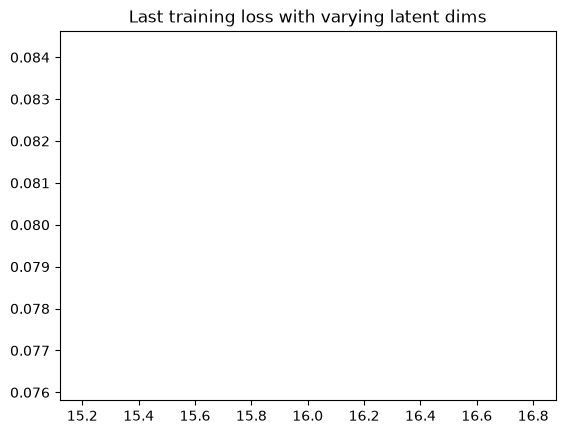

In [4]:
import matplotlib.pyplot as plt

plt.plot(latent_dims, last_val_losses)
plt.title("Last training loss with varying latent dims")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


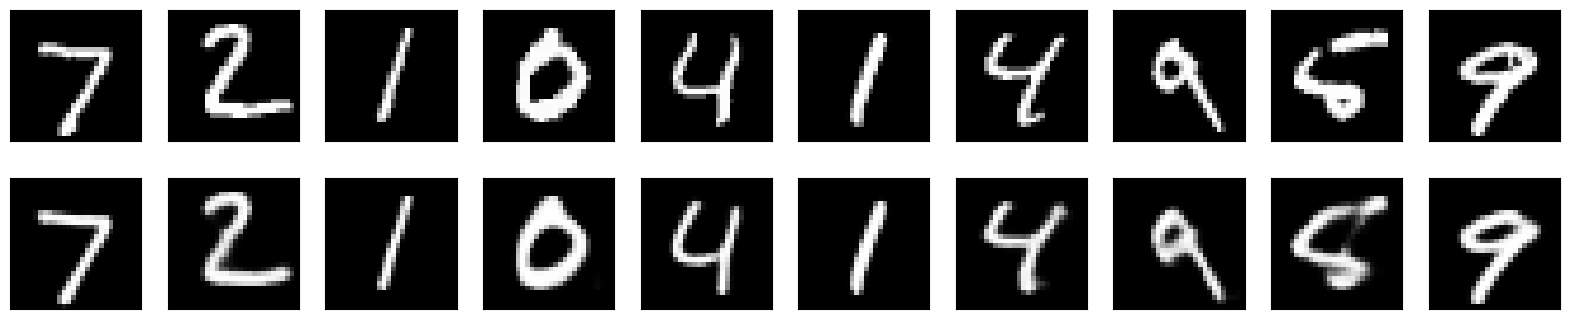

In [5]:
import matplotlib.pyplot as plt

index_autoencoder = 0

# Prédiction des données de test
decoded_imgs = autoencoders[index_autoencoder].predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Affichage de l'image originale
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Affichage de l'image reconstruite par l'auto-encodeur
    ax = plt.subplot(2, n, i+1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


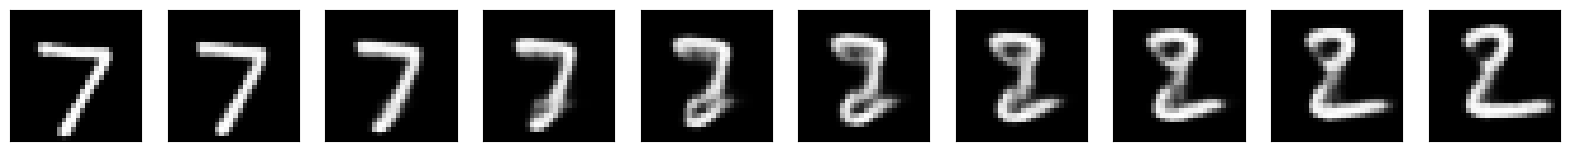

In [ ]:
trained_enc = encoders[0]
trained_dec = decoders[0]

z = trained_enc.predict(x_test)
z1 = z[0]
z2 = z[1]
I = trained_dec.predict(z)
n = 10

print(np.shape(x1))

plt.figure(figsize=(20, 2))
for i in range(10):
    z_i = (z1 + i*(z2 - z1) / 10).reshape(1, -1)
    I_i = trained_dec.predict(z_i)

    ax = plt.subplot(1, n, i+1)
    plt.imshow(I_i.reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()










































# Visages

In [1]:
import pandas as pd
import tarfile, tqdm, cv2, os
from sklearn.model_selection import train_test_split
import numpy as np

# Télécharger les données de la base de données "Labelled Faces in the Wild"
!wget https://acarlier.fr/tp/lfw_attributes.txt
!wget https://acarlier.fr/tp/lfw-deepfunneled.tgz
!wget https://acarlier.fr/tp/lfw.tgz

ATTRS_NAME = "lfw_attributes.txt"
IMAGES_NAME = "lfw-deepfunneled.tgz"
RAW_IMAGES_NAME = "lfw.tgz"

def decode_image_from_raw_bytes(raw_bytes):
    img = cv2.imdecode(np.asarray(bytearray(raw_bytes), dtype=np.uint8), 1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def load_lfw_dataset(
        use_raw=False,
        dx=80, dy=80,
        dimx=45, dimy=45):

    # Read attrs
    df_attrs = pd.read_csv(ATTRS_NAME, sep='\t', skiprows=1)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])
    imgs_with_attrs = set(map(tuple, df_attrs[["person", "imagenum"]].values))

    # Read photos
    all_photos = []
    photo_ids = []

    # tqdm in used to show progress bar while reading the data in a notebook here, you can change
    # tqdm_notebook to use it outside a notebook
    with tarfile.open(RAW_IMAGES_NAME if use_raw else IMAGES_NAME) as f:
        for m in tqdm.tqdm_notebook(f.getmembers()):
            # Only process image files from the compressed data
            if m.isfile() and m.name.endswith(".jpg"):
                # Prepare image
                img = decode_image_from_raw_bytes(f.extractfile(m).read())

                # Crop only faces and resize it
                img = img[dy:-dy, dx:-dx]
                img = cv2.resize(img, (dimx, dimy))

                # Parse person and append it to the collected data
                fname = os.path.split(m.name)[-1]
                fname_splitted = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(fname_splitted[:-1])
                photo_number = int(fname_splitted[-1])
                if (person_id, photo_number) in imgs_with_attrs:
                    all_photos.append(img)
                    photo_ids.append({'person': person_id, 'imagenum': photo_number})

    photo_ids = pd.DataFrame(photo_ids)
    all_photos = np.stack(all_photos).astype('uint8')

    # Preserve photo_ids order!
    all_attrs = photo_ids.merge(df_attrs, on=('person', 'imagenum')).drop(["person", "imagenum"], axis=1)

    return all_photos, all_attrs

# Prépare le dataset et le charge dans la variable X
X, attr = load_lfw_dataset(use_raw=True, dimx=32, dimy=32)
# Normalise les images
X = X/255
# Sépare les images en données d'entraînement et de test
X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)

--2026-09-28 11:58:25--  https://acarlier.fr/tp/lfw_attributes.txt
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving acarlier.fr (acarlier.fr)... 2a02:8424:80a2:c01:5edf:fb8c:21fa:ba98, 82.67.144.45
Connecting to acarlier.fr (acarlier.fr)|2a02:8424:80a2:c01:5edf:fb8c:21fa:ba98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14879205 (14M) [text/plain]
Saving to: ‘lfw_attributes.txt.1’

lfw_attributes.txt.   0%[                    ]       0  --.-KB/s               

lfw_attributes.txt. 100%[===================>]  14.19M  39.0MB/s    in 0.4s    

2026-09-28 11:58:26 (39.0 MB/s) - ‘lfw_attributes.txt.1’ saved [14879205/14879205]

--2026-09-28 11:58:26--  https://acarlier.fr/tp/lfw-deepfunneled.tgz
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving acarlier.fr (acarlier.fr)... 2a02:8424:80a2:c01:5edf:fb8c:21fa:ba98, 82.67.144.45
Connecting to acarlier.fr (acarlier.fr)|2a02:8424:80a2:c01:5edf:fb8c:21fa:ba98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 108770067 (104M) [application/octet-stream]
Saving to: ‘lfw-deepfunneled.tgz.1’

lfw-deepfunneled.tg 100%[===================>] 103.73M  47.2MB/s    in 2.2s    

2026-09-28 11:58:28 (47.2 MB/s) - ‘lfw-deepfunneled.tgz.1’ saved [108770067/108770067]

--2026-09-28 11:58:28--  https://acarlier.fr/tp/lfw.tgz
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving acarlier.fr (acarlier.fr)... 2a02:8424:80a2:c01:5edf:fb8c:21fa:ba98, 82.67.144.45
Conne

/tmp/ipykernel_47628/224347882.py:37: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for m in tqdm.tqdm_notebook(f.getmembers()):


  0%|          | 0/18983 [00:00<?, ?it/s]

In [2]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Conv2DTranspose, Reshape
from keras.models import Model
from matplotlib.axis import XAxis

epochs = 50

# Dimension de l'entrée
input_img = Input(shape=(32,32,3))

# Dimensions de l'espace latent : PARAMETRE A TESTER !!
latent_dims = [16]
last_val_losses = []
autoencoders = []
encoders = []
decoders = []

for l in latent_dims:
    print("Current latent dim :", l)

    # Définition d'un encodeur
    x = Conv2D(32, 3, activation='relu', padding="same")(input_img)
    x = MaxPooling2D((2, 2))(x)   # 32x32 -> 16x16

    x = Conv2D(64, 3, activation='relu', padding="same")(x)
    x = MaxPooling2D((2, 2))(x)   # 16x16 -> 8x8

    encoded = Flatten()(x)
    encoded = Dense(l, activation="linear")(encoded)


    # Définition d'un decodeur
    decoder_input = Input(shape=(l,))
    x = Dense(8 * 8 * 64, activation="relu")(decoder_input)
    x = Reshape((8, 8, 64))(x)
    x = Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    x = Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    decoded = Conv2D(3, 3, activation="sigmoid", padding="same")(x)


    # Construction d'un modèle séparé pour pouvoir accéder aux décodeur et encodeur
    encoder = Model(input_img, encoded)
    decoder = Model(decoder_input, decoded)

    # Construction du modèle de l'auto-encodeur
    encoded = encoder(input_img)
    decoded = decoder(encoded)
    autoencoder = Model(input_img, decoded)

    # Utilisation de l'erreur quadratique moyenne comme fonction de coût
    autoencoder.compile(optimizer='Adam', loss='bce')
    
    ## Train model
    history = autoencoder.fit(X_train, X_train,
                epochs=epochs,
                batch_size=128,
                shuffle=True,
                validation_data=(X_test, X_test))

    autoencoders.append(autoencoder)
    encoders.append(encoder)
    decoders.append(decoder)

    curr_last_loss = history.history['val_loss'][-1]
    last_val_losses.append(curr_last_loss)

I0000 00:00:1790589523.702046   47628 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Current latent dim : 16


I0000 00:00:1790589525.940625   47628 gpu_device.cc:2036] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4113 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
W0000 00:00:1790589527.231948   47628 cpu_allocator_impl.cc:174] Allocation of 145342464 exceeds 10% of free system memory.
W0000 00:00:1790589527.537941   47628 cpu_allocator_impl.cc:174] Allocation of 145342464 exceeds 10% of free system memory.
W0000 00:00:1790589527.706787   47628 cpu_allocator_impl.cc:174] Allocation of 145342464 exceeds 10% of free system memory.
W0000 00:00:1790589527.798703   47628 cpu_allocator_impl.cc:174] Allocation of 145342464 exceeds 10% of free system memory.


Epoch 1/50


I0000 00:00:1790589529.157709   47775 service.cc:154] XLA service 0x7f5a746bd1f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790589529.157729   47775 service.cc:170]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.4.0[615.71.9]; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790589529.203261   47775 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790589529.555894   47775 cuda_dnn.cc:442] Loaded cuDNN version 92600
I0000 00:00:1790589530.148357   47845 subprocess_compilation.cc:349] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 4 bytes spill stores, 4 bytes spill loads



17/93 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6807

I0000 00:00:1790589535.046539   47775 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


93/93 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - loss: 0.6603 - val_loss: 0.6381
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6290 - val_loss: 0.6251
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6222 - val_loss: 0.6206
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6186 - val_loss: 0.6174
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6166 - val_loss: 0.6163
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6156 - val_loss: 0.6156
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6149 - val_loss: 0.6152
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6144 - val_loss: 0.6148
Epoch 9/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6141 - val_loss: 0.6145
Epoch 10/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6139 - val_loss: 0.6144
Epoch 11/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6137 - val_loss: 0.6146
Epoch 12/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6136 - val_

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


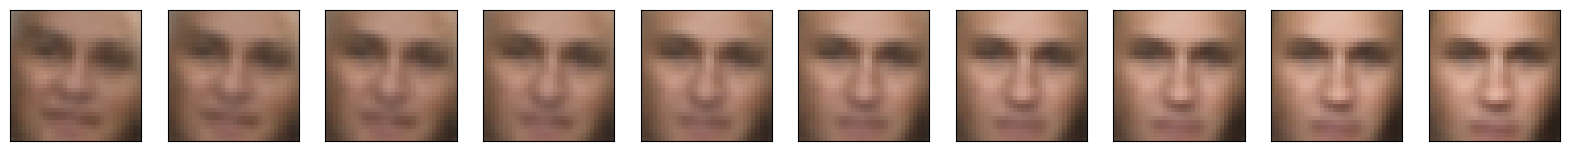

In [9]:
import matplotlib.pyplot as plt

trained_enc = encoders[0]
trained_dec = decoders[0]

z = trained_enc.predict(X_test)
z1 = z[2]
z2 = z[3]
I = trained_dec.predict(z)
n = 10

plt.figure(figsize=(20, 2))
for i in range(10):
    z_i = (z1 + i*(z2 - z1) / 10).reshape(1, -1)
    I_i = trained_dec.predict(z_i)

    ax = plt.subplot(1, n, i+1)
    plt.imshow(I_i[0])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()